In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

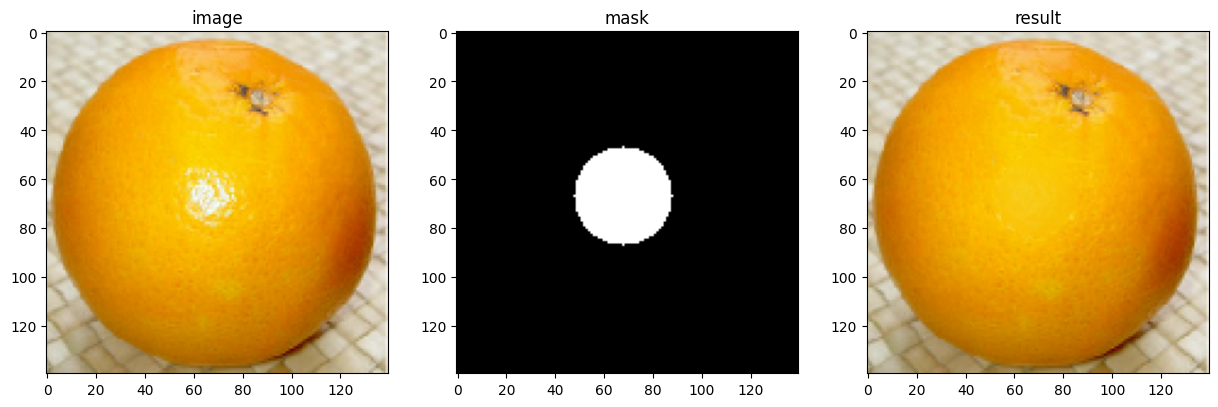

In [15]:
src = cv.imread("../../../class.vision/images/orange.png")
mask = cv.imread("../../../class.vision/images/orange-mask.png", 0)
mask = cv.threshold(mask, 127, 255, cv.THRESH_BINARY)[1]

cv.findContours(mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
M = cv.moments(mask)

cx = M['m10'] / M['m00']
cy = M['m01'] / M['m00']

mask = cv.merge([mask,mask,mask])

cv.circle(mask, (int(cx), int(cy)), 20, [255]*3, -1)
result = cv.illuminationChange(src, mask)


plt.figure(figsize=[15,12])
plt.subplot(131);plt.imshow(src[...,::-1]);plt.title("image");
plt.subplot(132);plt.imshow(mask, cmap='gray');plt.title("mask");
plt.subplot(133);plt.imshow(result[...,::-1]);plt.title("result");
